Predict the pedestal using EPEDNN-SC loop for ARC baseline scenario

In [1]:
import os
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sys
from pathlib import Path
import urllib.request # needed for geqdsk import
ROOT = Path.cwd().parent.parent.parent
sys.path.insert(0, str(ROOT))
from src.profiles_loop_solve import profiles_loop_solve

Authorization required, but no authorization protocol specified
Authorization required, but no authorization protocol specified


In [2]:
# Import the ARC baseline scenario geqdsk if it does not currently exist
_ZENODO = 'https://zenodo.org/records/19498373/files'

def _fetch(filename):
    if not os.path.exists(filename):
        print(f'Downloading {filename} from Zenodo...', end=' ', flush=True)
        urllib.request.urlretrieve(f'{_ZENODO}/{filename}?download=1', filename)
        print('done.')

mhd_fp = 'geqdsk-ARCv3a'
_fetch(mhd_fp) # places geqdsk file in the current directory

Loaded ne: 32 points (ne [10^20 particles/m^3])
Loaded Te: 43 points (Te [keV])


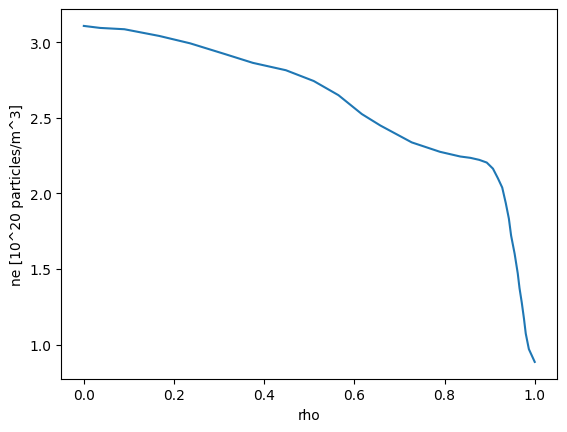

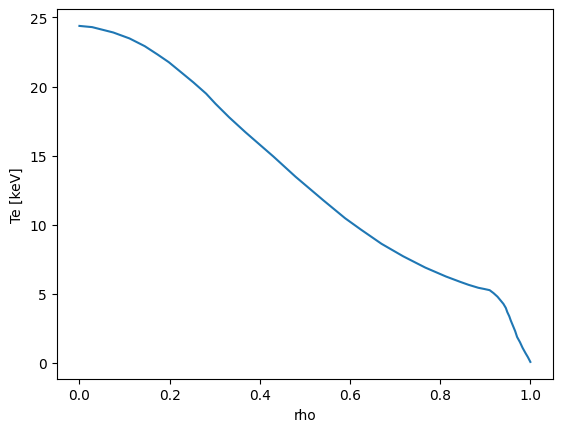

In [3]:
# Import reference profiles digitized from Howard et al. 2026 Fig. 4

def load_digitized_profile(filepath):
    """Load rho and profile data from a Web Plot Digitizer export.

    Parameters
    ----------
    filepath : str or Path
        Path to an ARC_*_extracted.txt file.

    Returns
    -------
    rho : ndarray
        Normalized radial coordinate.
    profile : ndarray
        ne in 10^20 m^-3 or Te in keV, depending on the file.
    quantity : str
        'ne' or 'Te'.
    units : str
        Unit string parsed from the file header.
    """
    filepath = Path(filepath)
    data_lines = []
    quantity = None
    units = None

    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.lower().startswith('rho,'):
                header = line
                if 'ne' in header.lower():
                    quantity = 'ne'
                elif 'te' in header.lower():
                    quantity = 'Te'
                units = header.split(',', 1)[1].strip()
                continue
            if quantity is not None:
                parts = [part.strip() for part in line.split(',')]
                if len(parts) == 2:
                    try:
                        data_lines.append((float(parts[0]), float(parts[1])))
                    except ValueError:
                        pass

    if not data_lines:
        raise ValueError(f'No profile data found in {filepath}')

    data = np.array(data_lines)
    sort_idx = np.argsort(data[:, 0])
    data = data[sort_idx]
    return data[:, 0], data[:, 1], quantity, units


ne_fp = 'ARC_ne_extracted.txt'
Te_fp = 'ARC_Te_extracted.txt'

rho_ne, ne_ref, _, ne_units = load_digitized_profile(ne_fp)
rho_Te, Te_ref, _, Te_units = load_digitized_profile(Te_fp)

np.save('ARC_ne_extracted.npy', {'rho': rho_ne, 'ne': ne_ref, 'units': ne_units})
np.save('ARC_Te_extracted.npy', {'rho': rho_Te, 'Te': Te_ref, 'units': Te_units})

print(f'Loaded ne: {len(rho_ne)} points ({ne_units})')
print(f'Loaded Te: {len(rho_Te)} points ({Te_units})')

fig,ax = plt.subplots()
ax.plot(rho_ne, ne_ref, label='ne')
ax.set_xlabel('rho')
ax.set_ylabel('ne [10^20 particles/m^3]')

fig1,ax1 = plt.subplots()
ax1.plot(rho_Te, Te_ref, label='Te')
ax1.set_xlabel('rho')
ax1.set_ylabel('Te [keV]')

manual_profs = {
    'ne': ne_ref,
    'Te': Te_ref,
    'rho_ne': rho_ne,
    'rho_Te': rho_Te
}


In [4]:
# Parameters for model #

# Output directory
output_dir = 'multiequil_kbmavg'

# Scan parameters
x_res = 20
free_params = {
    'alpha_crit': 0.1,
    'C_KBM': 0.1,
    'De_chie_etg': 0.1,
    'nFC_x0': 3.16228e15,
    'ncx_x0_ratio': 1.259
}
eped_tol_max = 1e-4
eped_iter_max = 50
EPEDNN_core = 'previous T, stiched ne'
kbm_treatment = "picard"
kbm_gate_eps = 0.1
picard_gate_mode = "average"
picard_relax = 1.0

verbose = False

In [ ]:
# Model run
ped_wid, ped_h_out, gfile_pres, gfile_pres_grid = profiles_loop_solve(
    MHD_FP = mhd_fp,
    kprof_loc = 'manual rho grid',
    manual_profs = manual_profs,
    P_tot_e = ( 21.5 + 0.8 + 227 ) * 0.5 * 1e6, # table 4 of Hillesheim et al. 2026
    ne_success_fp = output_dir,
    x_res = x_res,
    free_params = free_params,
    eped_tol_max = eped_tol_max,
    eped_iter_max = eped_iter_max,
    kbm_gate_eps = kbm_gate_eps,
    EPEDNN_core = EPEDNN_core,
    kbm_treatment = kbm_treatment,
    picard_gate_mode = picard_gate_mode,
    picard_relax = picard_relax,
    verbose = verbose,
)

Setting up EPEDNN...
Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Base model built.
betan: [1.21694598]
Pedestal height: 0.14197531070762642 MPa, Pedestal width: 0.04847637305380776 (psi_N)
Setting up EPEDNN...
betan: [2.01514102]
Pedestal height: 0.6855601582362734 MPa, Pedestal width: 0.11021946527124434 (psi_N)
Normalized pedestal pressure height and width tolerance: 5.102401923329838


┌ Warning: Extrapolation warning on bt=11.343645965522871 is above bound of 7.999000072479248
└ @ EPEDNN ~/software/saarelma-conner-ped/dependencies/EPEDNN.jl/src/EPEDNN.jl:86
┌ Warning: Extrapolation warning on bt=11.343645965522871 is above bound of 7.999000072479248
└ @ EPEDNN ~/software/saarelma-conner-ped/dependencies/EPEDNN.jl/src/EPEDNN.jl:86


Setting up EPEDNN...


ConvergenceError: Nonlinear solve failed to converge after 14 nonlinear iterations.
Reason:
   DIVERGED_LINE_SEARCH

┌ Warning: Extrapolation warning on neped=50.86343864620318 is above bound of 27.200000762939453
└ @ EPEDNN ~/software/saarelma-conner-ped/dependencies/EPEDNN.jl/src/EPEDNN.jl:86


In [ ]:
# Model output #

def pres_pred(ped_wid, gfile_pres, gfile_pres_grid):
    """
    Calculate pedestal pressure from pedestal width and MHD equilibrium file.
    """
    psiN_top = 1 - ped_wid
    return np.interp(psiN_top, gfile_pres_grid, gfile_pres)


p_gfile = pres_pred(ped_wid, gfile_pres, gfile_pres_grid)
out_dict = {
    'mhd_fp': mhd_fp,
    'profiles': manual_profs,
    'ped_h': ped_h_out,
    'ped_wid': ped_wid,
    'p_gfile': p_gfile,
}
np.save(output_dir+'/ARC_pedestal_prediction.npy', out_dict)

# Test

In [ ]:
from epednn_mit.models.sparc.tensorflow_model import generate_epednn_mit_sparc_tensorflow
from epednn_mit.utils.load import load_weights
from pathlib import Path
import numpy as np

root = Path(".../epednn_mit/models/sparc")
weights = load_weights(sorted(root.glob("*sparc*.pkl")))
model = generate_epednn_mit_sparc_tensorflow(weights)

x = np.atleast_2d([Ip, Bt, R, a, kappa, delta, neped, betan, zeff])
print(model.predict(x))  # [[ped_height, ped_width]]